In [8]:
import pandas as pd

def read_library(file_path):  
    return pd.read_excel(file_path, header=None).iloc[:, 0]

# 读取文库列表，从索引1开始
library = read_library('/home/liuycomputing/wsp_sequencing/data/FINAL.xlsx')
lib_len = len(library)

In [9]:
import pickle

def load_error_dict_pickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

In [10]:
file_folder = '/home/shaopengwang/wsp/picture/usedata/'
single_id_file_list = [
    'PB222_whole_error_dict_1.pkl',
    'bg192_whole_error_dict_1.pkl',
    'bg233_whole_error_dict_1.pkl',
    'bg252_whole_error_dict_1.pkl',
    'bg284_whole_error_dict_1.pkl',
    'bgjx29_whole_error_dict_1.pkl'
]
single_id_original_reads_list = [37338213, 33230323, 33667838, 34453215, 33468069, 34453215, 33468069, 32825376]

signle_ids_list = [1 - 1, 5000 - 1, 10000 - 1, 20000 - 1, 30000 - 1]

In [6]:
import numpy as np

def get_index_reads(library, error_dict, original_reads):
    zero_num = 0
    no_index_list, ok_index_list = [], []

    idxs, pcpm_reads, detected_idxs = [], [], []

    for idx, seq in enumerate(library):
        right_list = np.array(error_dict[idx]['Right'], dtype=float)
        deletion_list = np.array(error_dict[idx]['Deletion'], dtype=float)
        insertion_list = np.array(error_dict[idx]['Insertion'], dtype=float)
        substitution_list = np.array(error_dict[idx]['Substitution'], dtype=float)
        total_num = right_list + deletion_list + insertion_list + substitution_list

        if total_num[0] < 1:
            no_index_list.append((idx, seq, int(total_num[0])))  # 保存 index 和对应的 DNA 序列
            zero_num += 1
        if total_num[0] >= 1:
            ok_index_list.append((idx, seq, int(total_num[0])))  # 保存 index 和对应的 DNA 序列
            detected_idxs.append(idx)

        idxs.append(idx)
        pcpm_reads.append(total_num[0]/original_reads*1e6)

    return idxs, pcpm_reads, no_index_list, ok_index_list, detected_idxs

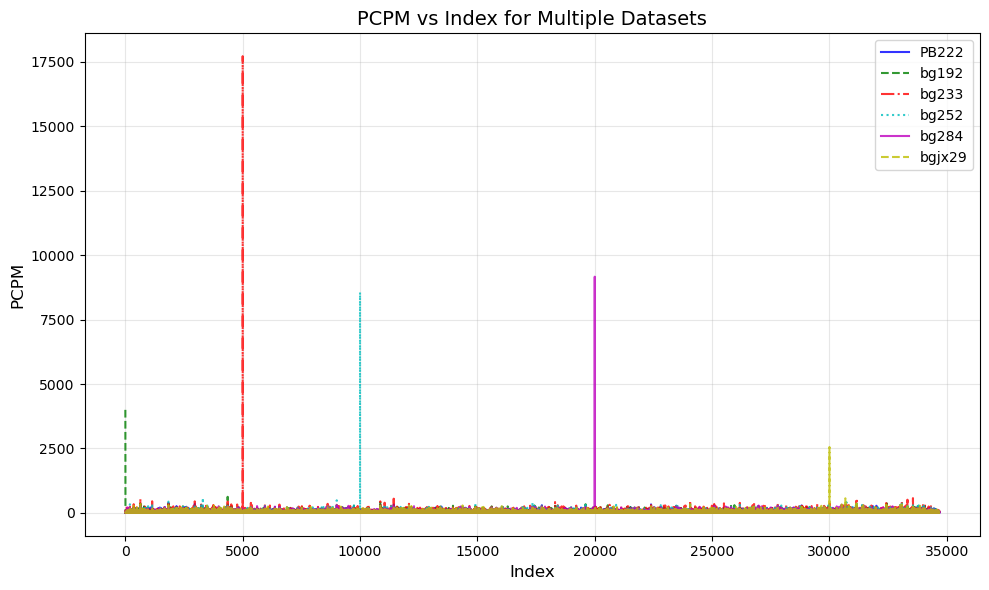

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 定义不同颜色或线型以区分不同曲线
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
line_styles = ['-', '--', '-.', ':', '-', '--']

# 用于存储图例标签
legend_labels = []

# 遍历所有文件
for idx, (file_name, original_reads) in enumerate(zip(single_id_file_list, single_id_original_reads_list)):
    # 加载数据
    single_id_error_dict = load_error_dict_pickle(file_path=file_folder + file_name)
    
    # 获取数据（根据实际情况可能需要调整detected_idxs参数）
    idxs, pcpm_reads, _, _, detected_idxs = get_index_reads(library, single_id_error_dict, original_reads)
    
    # 绘制曲线
    color_idx = idx % len(colors)
    style_idx = idx % len(line_styles)
    
    plt.plot(idxs, pcpm_reads, 
             color=colors[color_idx], 
             linestyle=line_styles[style_idx],
             linewidth=1.5,
             alpha=0.8)
    
    # 使用文件名（去掉扩展名）作为图例标签
    legend_label = file_name.replace('_whole_error_dict_1.pkl', '')
    legend_labels.append(legend_label)

# 添加标签和图例
plt.xlabel('Index', fontsize=12)
plt.ylabel('PCPM', fontsize=12)
plt.title('PCPM vs Index for Multiple Datasets', fontsize=14)
plt.legend(legend_labels, fontsize=10)
plt.grid(True, alpha=0.3)

# 如果需要，调整坐标轴范围
# plt.xlim([0, max_idxs])
# plt.ylim([0, max_pcpm])

plt.tight_layout()
plt.show()

In [11]:
# 创建一个空的DataFrame来收集所有数据
all_data_df = pd.DataFrame()

for idx, (file_name, original_reads) in enumerate(zip(single_id_file_list, single_id_original_reads_list)):
    # 1. 加载数据（使用你自己的函数）
    single_id_error_dict = load_error_dict_pickle(file_path=file_folder + file_name)
    
    # 2. 提取数据（使用你自己的函数）
    idxs, pcpm_reads, _, _, detected_idxs = get_index_reads(library, single_id_error_dict, original_reads)
    
    # 3. 为每个数据集创建临时的DataFrame
    # 使用有意义的列名，例如“Index_数据集名”和“PCPM_数据集名”
    temp_df = pd.DataFrame({
        f'Index_{file_name}': idxs,
        f'PCPM_{file_name}': pcpm_reads
    })
    
    # 4. 将临时DataFrame合并到总DataFrame中（按列合并）
    all_data_df = pd.concat([all_data_df, temp_df], axis=1)

# 5. 将所有数据导出为一个CSV文件（制表符分隔的txt文件也可）
output_path = '/home/liuycomputing/wsp_sequencing/codes/process_20251218/plot_figures/figure5_c_single_select_PCPM_data.csv'
all_data_df.to_csv(output_path, index=False, sep=',')  # 使用逗号分隔
print(f"数据已成功导出到：{output_path}")

数据已成功导出到：/home/liuycomputing/wsp_sequencing/codes/process_20251218/plot_figures/figure5_c_single_select_PCPM_data.csv
